# 06 — RQ2: Retrain SVM, DistilBERT và RoBERTa trên dataset mới

Notebook này nối tiếp đúng mạch của project:

`01_data_understanding.ipynb` → `02_data_cleanning.ipynb` → `03_EDA_visualization.ipynb` → `04_important_feature.ipynb` → **06_RQ2_retrain_SVM_DistilBERT_RoBERTa.ipynb**

## Mục tiêu RQ2

So sánh **Traditional ML** và **Transformer** trên cùng dữ liệu text đã làm sạch:

| # | Model | Input | Thiết lập chính |
|---|---|---|---|
| 1 | SVM | TF-IDF unigram + bigram | `LinearSVC(C=1.0)` |
| 2 | DistilBERT | `text_clean` | fine-tune `distilbert-base-uncased`, 3 epochs |
| 3 | RoBERTa | `text_clean` | fine-tune `roberta-base`, 3 epochs |

- **Dataset:** `data/processed/processed_data.csv`
- **Text:** `text_clean`
- **Label:** `0 = Human`, `1 = AI`
- **Split:** 80% Train / 20% Test, `stratify`, `random_state=42`
- **Metrics:** Accuracy, Precision, Recall, F1-score, ROC-AUC
- **Nguyên tắc:** Test set chỉ dùng để đánh giá cuối; không dùng để chọn epoch/hyperparameter.

> Đây là notebook **retrain** sau khi dataset thay đổi. Hyperparameter được giữ cố định để kết quả mới có thể đối chiếu với lần train trước.

## 0. Cài đặt thư viện (chỉ chạy nếu môi trường còn thiếu package)

In [4]:
# Nếu chạy trên Google Colab/Kaggle và thiếu thư viện, bỏ dấu # ở dòng dưới:
# %pip install -q "transformers>=4.41" accelerate scikit-learn pandas numpy matplotlib seaborn joblib

# Sau khi cài package lần đầu trên Colab, nếu được yêu cầu restart runtime thì restart rồi chạy lại từ đầu.

## 1. Import thư viện & cấu hình reproducibility

In [5]:
from pathlib import Path
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

import torch
from torch.utils.data import Dataset

try:
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        DataCollatorWithPadding,
        Trainer,
        TrainingArguments,
    )
except ImportError as e:
    raise ImportError(
        "Thiếu thư viện 'transformers'. Hãy chạy cell cài đặt ở mục 0 rồi restart kernel/runtime."
    ) from e

warnings.filterwarnings("ignore")

SEED = 42
TEST_SIZE = 0.20
MAX_FEATURES = 10_000
MAX_LENGTH = 512
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5

# Để False nếu chỉ cần metrics và không muốn lưu model Transformer nặng.
SAVE_TRANSFORMER_MODELS = False

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Seed: {SEED}")
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ DistilBERT/RoBERTa nên chạy trên GPU để tiết kiệm thời gian.")

Seed: 42
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 2. Xác định đường dẫn theo cấu trúc project

In [6]:
def find_project_root():
    # Tìm project root dựa trên cấu trúc data/processed hoặc thư mục src.
    start = Path.cwd().resolve()
    for folder in [start, *start.parents]:
        if (folder / "data" / "processed").exists() or (folder / "src").exists():
            return folder
    return start


PROJECT_ROOT = find_project_root()

# Ưu tiên đường dẫn chuẩn của nhóm nếu import được.
try:
    import sys
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    from src.path import PROCESSED_DATA_FILE as PROJECT_PROCESSED_DATA_FILE
except Exception:
    PROJECT_PROCESSED_DATA_FILE = None

candidate_files = [
    PROJECT_PROCESSED_DATA_FILE,
    PROJECT_ROOT / "data" / "processed" / "processed_data.csv",
    Path.cwd() / "data" / "processed" / "processed_data.csv",
    Path.cwd().parent / "data" / "processed" / "processed_data.csv",
    Path.cwd() / "processed_data.csv",
    Path("/mnt/data/processed_data.csv"),
]

PROCESSED_DATA_FILE = next(
    (Path(p) for p in candidate_files if p is not None and Path(p).exists()),
    None,
)

if PROCESSED_DATA_FILE is None:
    raise FileNotFoundError(
        "Không tìm thấy processed_data.csv. "
        "Hãy đặt file tại data/processed/processed_data.csv hoặc cập nhật PROCESSED_DATA_FILE."
    )

OUTPUT_DIR = PROJECT_ROOT / "results" / "rq2_retrain"
MODEL_DIR = OUTPUT_DIR / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 PROJECT_ROOT: {PROJECT_ROOT}")
print(f"📄 Dataset:      {PROCESSED_DATA_FILE}")
print(f"📊 Output:       {OUTPUT_DIR}")

📁 PROJECT_ROOT: C:\Users\HOME\Downloads
📄 Dataset:      c:\Users\HOME\Downloads\processed_data.csv
📊 Output:       C:\Users\HOME\Downloads\results\rq2_retrain


## 3. Load & validate dataset mới

In [7]:
df = pd.read_csv(PROCESSED_DATA_FILE)

text_col = "text_clean"
target_col = "label"

required_cols = {text_col, target_col}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise KeyError(
        f"Thiếu cột bắt buộc: {sorted(missing_cols)}. "
        f"Các cột hiện có: {df.columns.tolist()}"
    )

print("=" * 70)
print("DATASET SAU DATA CLEANING")
print("=" * 70)
print(f"Shape ban đầu: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Chỉ loại trường hợp bất thường còn sót; notebook 02 đã phải xử lý trước đó.
before = len(df)
df = df.dropna(subset=[text_col, target_col]).copy()
df[text_col] = df[text_col].astype(str).str.strip()
df = df[df[text_col].str.len() > 0].copy()
df[target_col] = pd.to_numeric(df[target_col], errors="raise").astype(int)
df = df.reset_index(drop=True)

if not set(df[target_col].unique()).issubset({0, 1}):
    raise ValueError(
        f"Label phải chỉ gồm 0/1, nhưng đang có: {sorted(df[target_col].unique())}"
    )

print(f"Số dòng bị loại do null/text rỗng: {before - len(df)}")
print(f"Shape dùng để train: {df.shape}")
print(f"Số text_clean trùng: {df.duplicated(subset=[text_col]).sum()}")

label_summary = pd.DataFrame({
    "count": df[target_col].value_counts().sort_index(),
    "percent": (
        df[target_col].value_counts(normalize=True).sort_index() * 100
    ).round(2),
})
label_summary.index = [
    "Human (0)" if i == 0 else "AI (1)"
    for i in label_summary.index
]

display(label_summary)

if "source" in df.columns:
    print(f"Số source: {df['source'].nunique()}")
if "prompt_name" in df.columns:
    print(f"Số prompt_name: {df['prompt_name'].nunique()}")

display(df.head())

DATASET SAU DATA CLEANING
Shape ban đầu: (44854, 5)
Columns: ['label', 'prompt_name', 'source', 'text_clean', 'word_count_clean']
Số dòng bị loại do null/text rỗng: 0
Shape dùng để train: (44854, 5)
Số text_clean trùng: 0


,count,percent
Human (0),27359,61.0
AI (1),17495,39.0


Số source: 17
Số prompt_name: 15


,label,prompt_name,source,text_clean,word_count_clean
0,0,Phones and driving,persuade_corpus,phones modern humans today are always on their...,379
1,0,Phones and driving,persuade_corpus,this essay will explain if drivers should or s...,366
2,0,Phones and driving,persuade_corpus,driving while the use of cellular devices toda...,178
3,0,Phones and driving,persuade_corpus,phones driving drivers should not be able to u...,211
4,0,Phones and driving,persuade_corpus,cell phone operation while driving the ability...,332


## 4. Chia Train/Test 80/20 — dùng CHUNG cho cả 3 model

Ta chia **một lần duy nhất** rồi dùng cùng `train_idx` / `test_idx` cho SVM, DistilBERT và RoBERTa.

**Test set không được dùng trong quá trình huấn luyện hoặc chọn checkpoint.**

In [8]:
all_idx = df.index.to_numpy()
y_all = df[target_col].to_numpy()

train_idx, test_idx = train_test_split(
    all_idx,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=SEED,
)

X_train = df.loc[train_idx, text_col].astype(str).reset_index(drop=True)
X_test = df.loc[test_idx, text_col].astype(str).reset_index(drop=True)
y_train = df.loc[train_idx, target_col].astype(int).reset_index(drop=True)
y_test = df.loc[test_idx, target_col].astype(int).reset_index(drop=True)

assert len(set(train_idx) & set(test_idx)) == 0
assert len(train_idx) + len(test_idx) == len(df)

print("=" * 70)
print("SPLIT 80% TRAIN / 20% TEST")
print("=" * 70)
print(f"Tổng:  {len(df):,}")
print(f"Train: {len(X_train):,} ({len(X_train)/len(df):.1%})")
print(f"Test:  {len(X_test):,} ({len(X_test)/len(df):.1%})")
print(f"Overlap Train/Test: {len(set(train_idx) & set(test_idx))}")
print(f"Tỷ lệ AI toàn bộ: {df[target_col].mean():.2%}")
print(f"Tỷ lệ AI Train:   {y_train.mean():.2%}")
print(f"Tỷ lệ AI Test:    {y_test.mean():.2%}")

split_manifest = pd.DataFrame({
    "row_id": np.concatenate([train_idx, test_idx]),
    "split": ["train"] * len(train_idx) + ["test"] * len(test_idx),
})
split_manifest.to_csv(OUTPUT_DIR / "split_manifest.csv", index=False)

print(f"💾 Đã lưu split manifest: {OUTPUT_DIR / 'split_manifest.csv'}")

SPLIT 80% TRAIN / 20% TEST
Tổng:  44,854
Train: 35,883 (80.0%)
Test:  8,971 (20.0%)
Overlap Train/Test: 0
Tỷ lệ AI toàn bộ: 39.00%
Tỷ lệ AI Train:   39.00%
Tỷ lệ AI Test:    39.00%
💾 Đã lưu split manifest: C:\Users\HOME\Downloads\results\rq2_retrain\split_manifest.csv


## 5. Hàm đánh giá dùng chung

In [9]:
results = {}

predictions = pd.DataFrame({
    "row_id": test_idx,
    "y_true": df.loc[test_idx, target_col].to_numpy(),
})

for col in ["prompt_name", "source"]:
    if col in df.columns:
        predictions[col] = df.loc[test_idx, col].to_numpy()


def calculate_metrics(
    y_true,
    y_pred,
    y_score,
    train_time_sec,
    inference_time_sec,
):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "Train_time_sec": train_time_sec,
        "Inference_time_sec": inference_time_sec,
    }


def show_evaluation(model_name, y_true, y_pred, metrics):
    print("\n" + "=" * 70)
    print(f"KẾT QUẢ — {model_name}")
    print("=" * 70)

    for key, value in metrics.items():
        if isinstance(value, (int, float, np.floating)):
            print(f"{key:20s}: {value:.4f}")
        else:
            print(f"{key:20s}: {value}")

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Human", "AI"],
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=["Human", "AI"],
        yticklabels=["Human", "AI"],
    )
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

## 6. Model 1 — SVM (TF-IDF + LinearSVC)

[1/3] TRAIN SVM — TF-IDF + LinearSVC

KẾT QUẢ — SVM
Accuracy            : 0.9967
Precision           : 0.9988
Recall              : 0.9926
F1-score            : 0.9957
ROC-AUC             : 0.9997
Train_time_sec      : 24.9859
Inference_time_sec  : 0.0093

Classification report:
              precision    recall  f1-score   support

       Human     0.9953    0.9993    0.9973      5472
          AI     0.9988    0.9926    0.9957      3499

    accuracy                         0.9967      8971
   macro avg     0.9971    0.9959    0.9965      8971
weighted avg     0.9967    0.9967    0.9967      8971



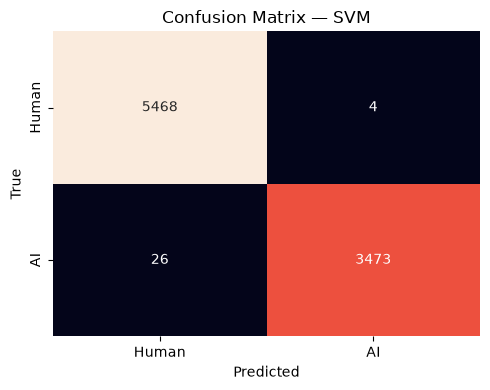

💾 Vectorizer: C:\Users\HOME\Downloads\results\rq2_retrain\models\svm_tfidf_vectorizer.joblib
💾 Model:      C:\Users\HOME\Downloads\results\rq2_retrain\models\svm_linearsvc.joblib


In [10]:
print("=" * 70)
print("[1/3] TRAIN SVM — TF-IDF + LinearSVC")
print("=" * 70)

train_start = time.perf_counter()

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svm_model = LinearSVC(
    C=1.0,
    random_state=SEED,
)

svm_model.fit(X_train_tfidf, y_train)
svm_train_time = time.perf_counter() - train_start

infer_start = time.perf_counter()
y_pred_svm = svm_model.predict(X_test_tfidf)
y_score_svm = svm_model.decision_function(X_test_tfidf)
svm_inference_time = time.perf_counter() - infer_start

results["SVM"] = calculate_metrics(
    y_test,
    y_pred_svm,
    y_score_svm,
    svm_train_time,
    svm_inference_time,
)

predictions["pred_SVM"] = y_pred_svm
predictions["score_SVM"] = y_score_svm

joblib.dump(tfidf, MODEL_DIR / "svm_tfidf_vectorizer.joblib")
joblib.dump(svm_model, MODEL_DIR / "svm_linearsvc.joblib")

show_evaluation(
    "SVM",
    y_test,
    y_pred_svm,
    results["SVM"],
)

print(f"💾 Vectorizer: {MODEL_DIR / 'svm_tfidf_vectorizer.joblib'}")
print(f"💾 Model:      {MODEL_DIR / 'svm_linearsvc.joblib'}")

## 7. Dataset & helper cho Transformer


Cả DistilBERT và RoBERTa được train đủ `NUM_EPOCHS = 3` trên 80% Train rồi mới đánh giá trên cùng 20% Test.

`DataCollatorWithPadding` dùng **dynamic padding theo batch**, tiết kiệm bộ nhớ hơn padding toàn bộ dữ liệu lên 512 token.

In [11]:
class EncodedTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.astype(int).tolist()

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(values[idx])
            for key, values in self.encodings.items()
        }
        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long,
        )
        return item

    def __len__(self):
        return len(self.labels)


def logits_to_predictions(logits):
    logits_tensor = torch.tensor(logits)
    probs = torch.softmax(logits_tensor, dim=-1).numpy()
    y_pred = np.argmax(probs, axis=1)
    y_score = probs[:, 1]
    return y_pred, y_score


def train_transformer(
    model_label,
    model_name,
    train_texts,
    train_labels,
    test_texts,
    test_labels,
):
    print("\n" + "=" * 70)
    print(f"TRAIN {model_label}: {model_name}")
    print("=" * 70)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    print("Tokenizing Train...")
    train_encodings = tokenizer(
        train_texts.tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

    print("Tokenizing Test...")
    test_encodings = tokenizer(
        test_texts.tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

    train_dataset = EncodedTextDataset(
        train_encodings,
        train_labels,
    )
    test_dataset = EncodedTextDataset(
        test_encodings,
        test_labels,
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
    )

    model_output_dir = (
        MODEL_DIR / model_label.lower().replace(" ", "_")
    )

    training_args = TrainingArguments(
        output_dir=str(model_output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=0.01,
        seed=SEED,
        data_seed=SEED,
        report_to="none",
        logging_steps=100,
        save_strategy="no",
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=data_collator,
    )

    train_start = time.perf_counter()
    trainer.train()
    train_time_sec = time.perf_counter() - train_start

    # Test chỉ được dùng sau khi train đã hoàn tất.
    infer_start = time.perf_counter()
    prediction_output = trainer.predict(test_dataset)
    inference_time_sec = time.perf_counter() - infer_start

    y_pred, y_score = logits_to_predictions(
        prediction_output.predictions
    )

    metrics = calculate_metrics(
        test_labels,
        y_pred,
        y_score,
        train_time_sec,
        inference_time_sec,
    )

    if SAVE_TRANSFORMER_MODELS:
        final_dir = model_output_dir / "final"
        final_dir.mkdir(parents=True, exist_ok=True)
        trainer.save_model(str(final_dir))
        tokenizer.save_pretrained(str(final_dir))
        print(f"💾 Đã lưu model tại: {final_dir}")
    else:
        print(
            "ℹ️ SAVE_TRANSFORMER_MODELS=False → "
            "không lưu weight Transformer để tiết kiệm dung lượng."
        )

    return metrics, y_pred, y_score, trainer, tokenizer

## 8. Model 2 — DistilBERT

[2/3] DistilBERT

TRAIN DistilBERT: distilbert-base-uncased


Tokenizing Train...
Tokenizing Test...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.289247
200,0.099571
300,0.062214
400,0.098329
500,0.075511
600,0.071542
700,0.038840
800,0.106655
900,0.039750
1000,0.041952


ℹ️ SAVE_TRANSFORMER_MODELS=False → không lưu weight Transformer để tiết kiệm dung lượng.

KẾT QUẢ — DistilBERT
Accuracy            : 0.9962
Precision           : 0.9932
Recall              : 0.9971
F1-score            : 0.9952
ROC-AUC             : 0.9999
Train_time_sec      : 4396.5970
Inference_time_sec  : 105.1428

Classification report:
              precision    recall  f1-score   support

       Human     0.9982    0.9956    0.9969      5472
          AI     0.9932    0.9971    0.9952      3499

    accuracy                         0.9962      8971
   macro avg     0.9957    0.9964    0.9960      8971
weighted avg     0.9962    0.9962    0.9962      8971



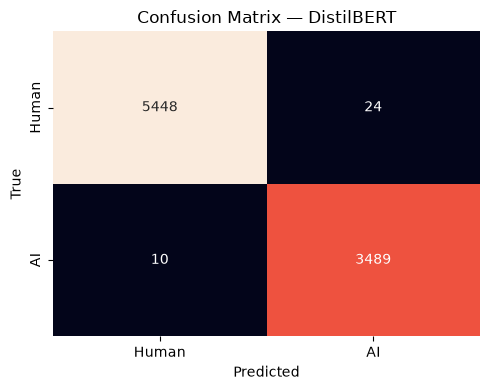

In [12]:
print("[2/3] DistilBERT")

(
    distil_metrics,
    y_pred_distil,
    y_score_distil,
    trainer_distil,
    tokenizer_distil,
) = train_transformer(
    model_label="DistilBERT",
    model_name="distilbert-base-uncased",
    train_texts=X_train,
    train_labels=y_train,
    test_texts=X_test,
    test_labels=y_test,
)

results["DistilBERT"] = distil_metrics
predictions["pred_DistilBERT"] = y_pred_distil
predictions["score_DistilBERT"] = y_score_distil

show_evaluation(
    "DistilBERT",
    y_test,
    y_pred_distil,
    results["DistilBERT"],
)

del trainer_distil
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 9. Model 3 — RoBERTa

[3/3] RoBERTa

TRAIN RoBERTa: roberta-base
Tokenizing Train...
Tokenizing Test...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.282045
200,0.099119
300,0.105156
400,0.050325
500,0.087860
600,0.121823
700,0.066035
800,0.058177
900,0.033938
1000,0.063522


ℹ️ SAVE_TRANSFORMER_MODELS=False → không lưu weight Transformer để tiết kiệm dung lượng.

KẾT QUẢ — RoBERTa
Accuracy            : 0.9953
Precision           : 0.9890
Recall              : 0.9991
F1-score            : 0.9940
ROC-AUC             : 0.9999
Train_time_sec      : 9080.5676
Inference_time_sec  : 207.2404

Classification report:
              precision    recall  f1-score   support

       Human     0.9994    0.9929    0.9961      5472
          AI     0.9890    0.9991    0.9940      3499

    accuracy                         0.9953      8971
   macro avg     0.9942    0.9960    0.9951      8971
weighted avg     0.9954    0.9953    0.9953      8971



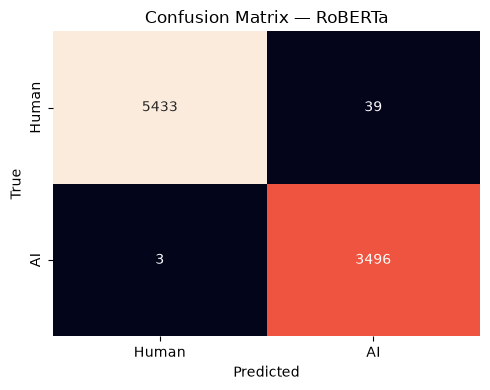

In [13]:
print("[3/3] RoBERTa")

(
    roberta_metrics,
    y_pred_roberta,
    y_score_roberta,
    trainer_roberta,
    tokenizer_roberta,
) = train_transformer(
    model_label="RoBERTa",
    model_name="roberta-base",
    train_texts=X_train,
    train_labels=y_train,
    test_texts=X_test,
    test_labels=y_test,
)

results["RoBERTa"] = roberta_metrics
predictions["pred_RoBERTa"] = y_pred_roberta
predictions["score_RoBERTa"] = y_score_roberta

show_evaluation(
    "RoBERTa",
    y_test,
    y_pred_roberta,
    results["RoBERTa"],
)

del trainer_roberta
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 10. Tổng hợp kết quả 3 model

In [14]:
results_df = pd.DataFrame(results).T
results_df.index.name = "Model"

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
]
time_cols = [
    "Train_time_sec",
    "Inference_time_sec",
]

print("\n" + "=" * 90)
print("BẢNG SO SÁNH 3 MODEL — RQ2")
print("=" * 90)

display(
    results_df[metric_cols + time_cols].round(4)
)

best_model = results_df["F1-score"].idxmax()
best_f1 = results_df.loc[best_model, "F1-score"]

print(
    f"\nModel có F1-score cao nhất trên test: "
    f"{best_model} ({best_f1:.4f})"
)

summary_path = (
    OUTPUT_DIR / "rq2_model_comparison_results.csv"
)
results_df.round(6).to_csv(
    summary_path,
    encoding="utf-8-sig",
)

prediction_path = (
    OUTPUT_DIR / "rq2_test_predictions.csv"
)
predictions.to_csv(
    prediction_path,
    index=False,
    encoding="utf-8-sig",
)

print(f"💾 Summary:     {summary_path}")
print(f"💾 Predictions: {prediction_path}")


BẢNG SO SÁNH 3 MODEL — RQ2


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Train_time_sec,Inference_time_sec
Model,,,,,,,
SVM,0.9967,0.9988,0.9926,0.9957,0.9997,24.9859,0.0093
DistilBERT,0.9962,0.9932,0.9971,0.9952,0.9999,4396.5970,105.1428
RoBERTa,0.9953,0.9890,0.9991,0.9940,0.9999,9080.5676,207.2404



Model có F1-score cao nhất trên test: SVM (0.9957)
💾 Summary:     C:\Users\HOME\Downloads\results\rq2_retrain\rq2_model_comparison_results.csv
💾 Predictions: C:\Users\HOME\Downloads\results\rq2_retrain\rq2_test_predictions.csv


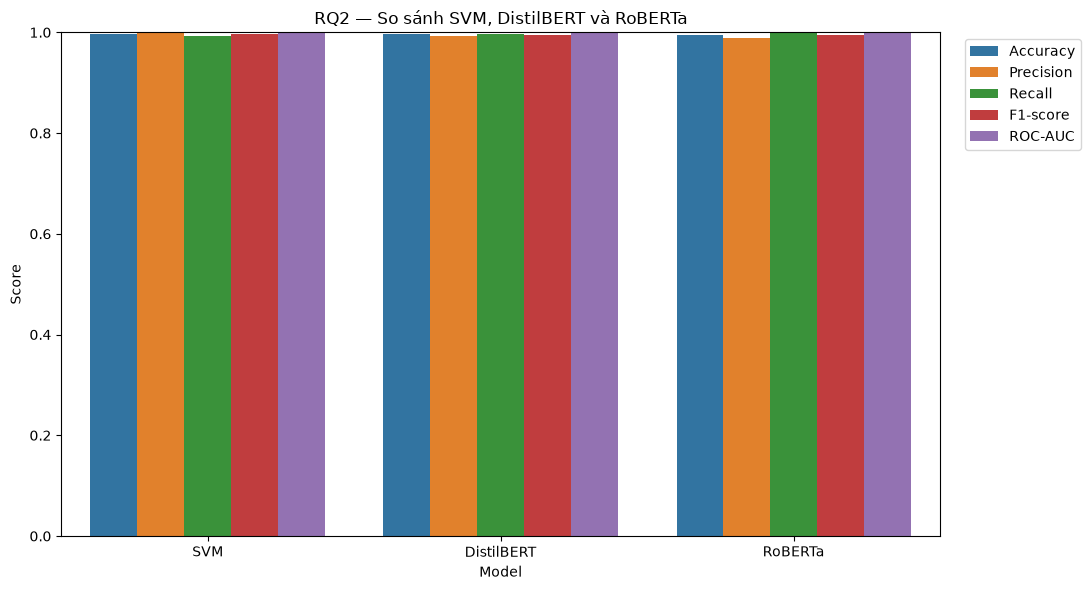

💾 Figure: C:\Users\HOME\Downloads\results\rq2_retrain\rq2_model_comparison.png


In [15]:
plot_df = (
    results_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC",
        ]
    ]
    .reset_index()
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score",
    )
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric",
)
plt.title("RQ2 — So sánh SVM, DistilBERT và RoBERTa")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()

figure_path = (
    OUTPUT_DIR / "rq2_model_comparison.png"
)
plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"💾 Figure: {figure_path}")

## 11. Error analysis sơ bộ theo `source` (nếu có)

In [16]:
if "source" in predictions.columns:
    error_rows = []

    for model_name, pred_col in [
        ("SVM", "pred_SVM"),
        ("DistilBERT", "pred_DistilBERT"),
        ("RoBERTa", "pred_RoBERTa"),
    ]:
        temp = predictions.copy()
        temp["correct"] = (
            temp[pred_col] == temp["y_true"]
        ).astype(int)

        source_perf = (
            temp.groupby("source")
            .agg(
                n=("y_true", "size"),
                accuracy=("correct", "mean"),
            )
            .reset_index()
        )
        source_perf["Model"] = model_name
        error_rows.append(source_perf)

    source_results = pd.concat(
        error_rows,
        ignore_index=True,
    )

    source_results = source_results.sort_values(
        ["Model", "accuracy", "n"]
    )

    display(source_results.head(30))

    source_path = (
        OUTPUT_DIR / "rq2_performance_by_source.csv"
    )
    source_results.to_csv(
        source_path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"💾 Performance by source: {source_path}"
    )
else:
    print(
        "Dataset không có cột 'source' → "
        "bỏ qua phân tích theo source."
    )

,source,n,accuracy,Model
25,llama_70b_v1,210,0.985714,DistilBERT
19,cohere-command,80,0.987500,DistilBERT
27,mistral7binstruct_v2,486,0.989712,DistilBERT
30,persuade_corpus,5179,0.995366,DistilBERT
33,train_essays,294,0.996599,DistilBERT
32,radekgpt4,48,1.000000,DistilBERT
29,palm-text-bison1,68,1.000000,DistilBERT
28,mistralai/Mistral-7B-Instruct-v0.1,80,1.000000,DistilBERT
17,NousResearch/Llama-2-7b-chat-hf,89,1.000000,DistilBERT
31,radek_500,112,1.000000,DistilBERT


💾 Performance by source: C:\Users\HOME\Downloads\results\rq2_retrain\rq2_performance_by_source.csv


## 12. Output dùng cho report / paper

Sau khi chạy xong notebook, thư mục `results/rq2_retrain/` sẽ có:

- `rq2_model_comparison_results.csv` — metric của 3 model
- `rq2_test_predictions.csv` — prediction từng mẫu test, dùng cho error analysis
- `rq2_model_comparison.png` — biểu đồ so sánh
- `split_manifest.csv` — lưu đúng split Train/Test để tái lập thí nghiệm
- `models/svm_tfidf_vectorizer.joblib`
- `models/svm_linearsvc.joblib`
- `rq2_performance_by_source.csv` — nếu dataset có cột `source`

### Lưu ý khi báo cáo kết quả

1. Cả 3 model phải dùng **cùng split**.
2. Không dùng test set để tune hyperparameter/chọn checkpoint.
3. Khi dataset thay đổi, cần ghi rõ phiên bản/số mẫu của dataset khi so với kết quả cũ.
4. Với RQ3 (seen/unseen LLM), nên tạo split theo `source` riêng thay vì dùng random split của RQ2.